In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [7]:


PATH = PATH = r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/'  

orders      = pd.read_csv(PATH + 'blinkit_orders.csv')
customers   = pd.read_csv(PATH + 'blinkit_customers.csv')
products    = pd.read_csv(PATH + 'blinkit_products.csv')
order_items = pd.read_csv(PATH + 'blinkit_order_items.csv')
delivery    = pd.read_csv(PATH + 'blinkit_delivery_performance.csv')
feedback    = pd.read_csv(PATH + 'blinkit_customer_feedback.csv')
inventory   = pd.read_csv(PATH + 'blinkit_inventory.csv')
marketing   = pd.read_csv(PATH + 'blinkit_marketing_performance.csv')

print("✅ All files loaded!")
print(f"Orders      : {orders.shape}")
print(f"Customers   : {customers.shape}")
print(f"Products    : {products.shape}")
print(f"Order Items : {order_items.shape}")
print(f"Delivery    : {delivery.shape}")
print(f"Feedback    : {feedback.shape}")
print(f"Inventory   : {inventory.shape}")
print(f"Marketing   : {marketing.shape}")

✅ All files loaded!
Orders      : (50000, 10)
Customers   : (25000, 11)
Products    : (237, 10)
Order Items : (225238, 5)
Delivery    : (50000, 8)
Feedback    : (50000, 8)
Inventory   : (259752, 4)
Marketing   : (9864, 11)


In [8]:
# See first 5 rows
print("=== First 5 rows ===")
display(orders.head())

=== First 5 rows ===


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,2850500678,97145527,2024-03-29 01:27:15,2024-03-29 01:46:15,2024-03-29 01:59:15,Slightly Delayed,4817.54,Cash,32423,6208603997
1,7171106490,45835229,2023-08-17 15:46:27,2023-08-17 15:59:27,2023-08-17 15:57:27,On Time,922.44,Cash,2312,9321628569
2,3829771237,25578646,2023-11-23 23:46:22,2023-11-24 00:05:22,2023-11-24 00:08:22,On Time,4154.91,Cash,87568,1297200837
3,459643984,68711385,2025-07-17 17:33:23,2025-07-17 17:51:23,2025-07-17 17:52:23,On Time,2682.11,Wallet,96765,7354302450
4,1316777473,52002897,2023-12-16 13:15:48,2023-12-16 13:34:48,2023-12-16 14:01:48,Significantly Delayed,1861.67,Cash,43840,309610785


In [9]:
# See column names and data types
print("=== Column Names & Data Types ===")
print(orders.dtypes)

=== Column Names & Data Types ===
order_id                    int64
customer_id                 int64
order_date                 object
promised_delivery_time     object
actual_delivery_time       object
delivery_status            object
order_total               float64
payment_method             object
delivery_partner_id         int64
store_id                    int64
dtype: object


In [10]:
# Check for missing values in ALL tables
print("=== MISSING VALUES CHECK ===\n")

all_tables = {
    'orders'      : orders,
    'customers'   : customers,
    'products'    : products,
    'order_items' : order_items,
    'delivery'    : delivery,
    'feedback'    : feedback,
    'inventory'   : inventory,
    'marketing'   : marketing
}

for name, df in all_tables.items():
    nulls = df.isnull().sum().sum()
    status = '✅ No missing values' if nulls == 0 else f'⚠️  {nulls} missing values'
    print(f"{name:<15} {status}")

=== MISSING VALUES CHECK ===

orders          ✅ No missing values
customers       ✅ No missing values
products        ✅ No missing values
order_items     ✅ No missing values
delivery        ⚠️  19199 missing values
feedback        ✅ No missing values
inventory       ✅ No missing values
marketing       ✅ No missing values


In [11]:
# Convert order_date from text to proper date
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Extract useful time columns
orders['year']       = orders['order_date'].dt.year
orders['month']      = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.strftime('%b')   # Jan, Feb...
orders['day_name']   = orders['order_date'].dt.strftime('%A')   # Monday...
orders['hour']       = orders['order_date'].dt.hour
orders['quarter']    = orders['order_date'].dt.quarter
orders['year_month'] = orders['order_date'].dt.to_period('M').astype(str)

print("✅ Orders dates fixed!")
print(orders[['order_date','year','month','month_name','day_name','hour']].head())

✅ Orders dates fixed!
           order_date  year  month month_name  day_name  hour
0 2024-03-29 01:27:15  2024      3        Mar    Friday     1
1 2023-08-17 15:46:27  2023      8        Aug  Thursday    15
2 2023-11-23 23:46:22  2023     11        Nov  Thursday    23
3 2025-07-17 17:33:23  2025      7        Jul  Thursday    17
4 2023-12-16 13:15:48  2023     12        Dec  Saturday    13


In [12]:
# Fill missing reasons (blank = on time, not an error)
delivery['reasons_if_delayed'] = delivery['reasons_if_delayed'].fillna('On Time')

# Negative delivery time means early delivery → treat as 0 delay
delivery['delay_minutes'] = delivery['delivery_time_minutes'].clip(lower=0)

print("✅ Delivery table fixed!")
print(delivery[['delivery_status','delay_minutes','reasons_if_delayed']].head())

✅ Delivery table fixed!
         delivery_status  delay_minutes reasons_if_delayed
0       Slightly Delayed           13.0            Traffic
1                On Time            0.0            On Time
2                On Time            3.0            Traffic
3                On Time            1.0            Traffic
4  Significantly Delayed           27.0            Traffic


In [13]:
customers['registration_date'] = pd.to_datetime(customers['registration_date'])
feedback['feedback_date']      = pd.to_datetime(feedback['feedback_date'])
marketing['date']              = pd.to_datetime(marketing['date'])
inventory['date']              = pd.to_datetime(inventory['date'], dayfirst=True)

print("✅ All dates fixed!")

✅ All dates fixed!


In [14]:
# Add category & margin info to each order item
order_items = order_items.merge(
    products[['product_id', 'category', 'brand', 'margin_percentage']],
    on='product_id',
    how='left'
)

print("✅ Category added to order_items!")
print(order_items.head())

✅ Category added to order_items!
     order_id  product_id  quantity  unit_price  total_price  \
0  2850500678      288845         2      967.07       967.07   
1  2850500678      665753         1      447.07      1341.21   
2  2850500678      619322         1      948.26      1896.52   
3  2850500678      728347         2      974.81      2924.43   
4  2850500678      513638         2      590.80      1181.60   

              category                          brand  margin_percentage  
0            Baby Care  Kothari, Badami and Nagarajan               30.0  
1  Fruits & Vegetables        Chopra, Johal and Garde               25.0  
2    Snacks & Munchies         Deol, Mandal and Kumar               35.0  
3       Household Care                    Saxena-Nori               25.0  
4       Household Care                Chaudhari Group               25.0  


In [15]:
# Join customer area and segment into orders
master = orders.merge(
    customers[['customer_id', 'area', 'customer_segment']],
    on='customer_id',
    how='left'
)

print("✅ Master table created!")
print(f"Shape: {master.shape}")
print(master[['order_id','order_total','area','customer_segment','month_name']].head())

✅ Master table created!
Shape: (50000, 19)
     order_id  order_total     area customer_segment month_name
0  2850500678      4817.54    Hosur          Premium        Mar
1  7171106490       922.44   Rajkot          Regular        Aug
2  3829771237      4154.91   Nagpur         Inactive        Nov
3   459643984      2682.11  Gurgaon          Regular        Jul
4  1316777473      1861.67   Kanpur              New        Dec


In [16]:
total_sales     = orders['order_total'].sum()
total_orders    = orders['order_id'].nunique()
total_customers = orders['customer_id'].nunique()
avg_order_value = orders['order_total'].mean()

print(f"💰 Total Sales       : ₹{total_sales:,.2f}")
print(f"🛒 Total Orders      : {total_orders:,}")
print(f"👥 Unique Customers  : {total_customers:,}")
print(f"🧾 Avg Order Value   : ₹{avg_order_value:,.2f}")

💰 Total Sales       : ₹116,235,457.87
🛒 Total Orders      : 50,000
👥 Unique Customers  : 21,671
🧾 Avg Order Value   : ₹2,324.71


In [17]:
on_time_pct      = (delivery['delivery_status'] == 'On Time').mean() * 100
avg_delay        = delivery[delivery['delay_minutes'] > 0]['delay_minutes'].mean()

print(f"✅ On-Time Delivery  : {on_time_pct:.1f}%")
print(f"⏱️  Avg Delay (mins)  : {avg_delay:.1f} mins")

✅ On-Time Delivery  : 70.2%
⏱️  Avg Delay (mins)  : 8.6 mins


In [18]:
repeat_customers = (customers['total_orders'] > 1).sum()
repeat_rate      = repeat_customers / len(customers) * 100
avg_rating       = feedback['rating'].mean()

print(f"🔄 Repeat Customers  : {repeat_customers:,}")
print(f"🔄 Repeat Rate       : {repeat_rate:.1f}%")
print(f"⭐ Avg Rating        : {avg_rating:.2f} / 5")

🔄 Repeat Customers  : 23,806
🔄 Repeat Rate       : 95.2%
⭐ Avg Rating        : 4.05 / 5


In [19]:
print("=" * 45)
print("       📊 BLINKIT — KEY METRICS")
print("=" * 45)
print(f"  💰 Total Sales         : ₹{total_sales:>15,.2f}")
print(f"  🛒 Total Orders        : {total_orders:>18,}")
print(f"  👥 Unique Customers    : {total_customers:>18,}")
print(f"  🧾 Avg Order Value     : ₹{avg_order_value:>15,.2f}")
print(f"  ✅ On-Time Delivery %  : {on_time_pct:>17.1f}%")
print(f"  ⏱️  Avg Delay (mins)    : {avg_delay:>18.1f}")
print(f"  🔄 Repeat Rate         : {repeat_rate:>17.1f}%")
print(f"  ⭐ Avg Rating          : {avg_rating:>18.2f}")
print("=" * 45)

       📊 BLINKIT — KEY METRICS
  💰 Total Sales         : ₹ 116,235,457.87
  🛒 Total Orders        :             50,000
  👥 Unique Customers    :             21,671
  🧾 Avg Order Value     : ₹       2,324.71
  ✅ On-Time Delivery %  :              70.2%
  ⏱️  Avg Delay (mins)    :                8.6
  🔄 Repeat Rate         :              95.2%
  ⭐ Avg Rating          :               4.05


In [20]:
# Group sales by month
monthly_sales = orders.groupby('year_month')['order_total'].sum().reset_index()
monthly_sales.columns = ['year_month', 'total_sales']

print(monthly_sales.head(10))

  year_month  total_sales
0    2023-01   3280875.78
1    2023-02   3059489.64
2    2023-03   3418506.79
3    2023-04   3233745.73
4    2023-05   3382405.31
5    2023-06   3179426.71
6    2023-07   3254625.02
7    2023-08   3219135.90
8    2023-09   3142462.40
9    2023-10   3251578.93


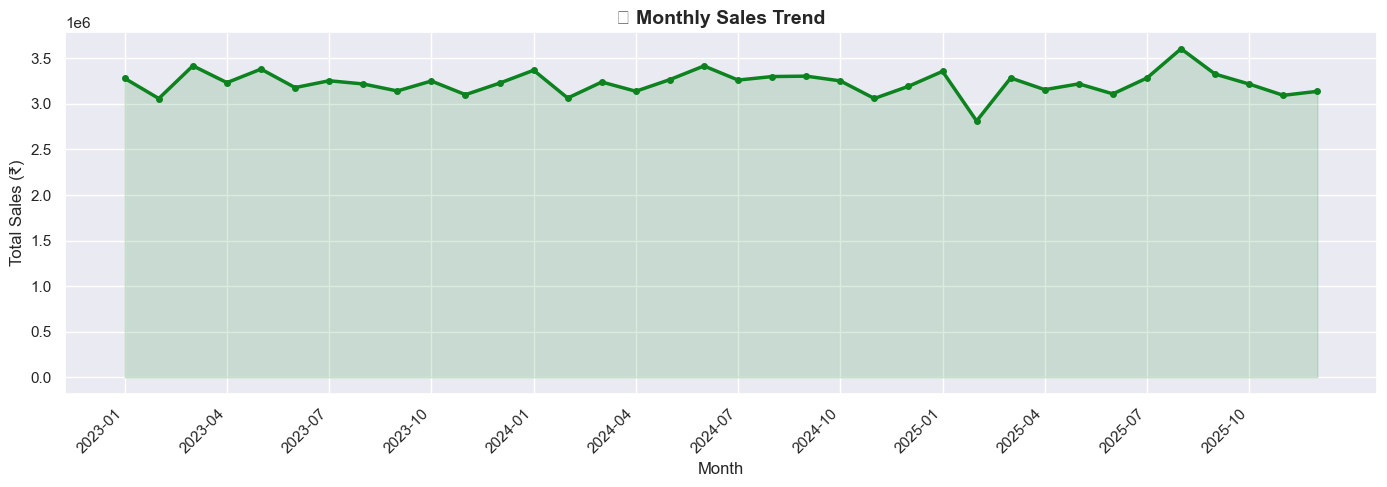

✅ Chart saved!


In [21]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales['year_month'], monthly_sales['total_sales'],
         color='#0C831F', linewidth=2.5, marker='o', markersize=4)

plt.fill_between(monthly_sales['year_month'], monthly_sales['total_sales'],
                 alpha=0.15, color='#0C831F')

plt.title('📈 Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (₹)')

# Show only every 3rd month label so it doesn't crowd
step = max(1, len(monthly_sales) // 12)
plt.xticks(range(0, len(monthly_sales), step),
           monthly_sales['year_month'][::step],
           rotation=45, ha='right')

plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/01_monthly_sales.png', dpi=150)
plt.show()
print("✅ Chart saved!")

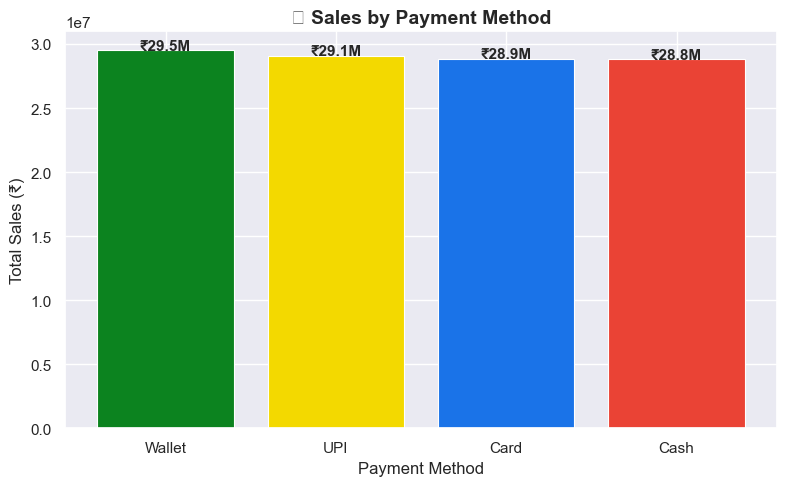

✅ Chart saved!


In [22]:
pay_sales = orders.groupby('payment_method')['order_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

colors = ['#0C831F', '#F3D900', '#1a73e8', '#ea4335']
bars = plt.bar(pay_sales.index, pay_sales.values, color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, pay_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 50000,
             f'₹{val/1e6:.1f}M',
             ha='center', fontsize=11, fontweight='bold')

plt.title('💳 Sales by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/02_payment_sales.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [23]:
# Count orders per hour
hour_orders = orders.groupby('hour')['order_id'].count().reset_index()
hour_orders.columns = ['hour', 'total_orders']

print(hour_orders)

    hour  total_orders
0      0          2172
1      1          2080
2      2          2028
3      3          2094
4      4          2096
5      5          2095
6      6          2018
7      7          2102
8      8          2057
9      9          2123
10    10          2067
11    11          2012
12    12          2105
13    13          2073
14    14          2106
15    15          2014
16    16          2121
17    17          2118
18    18          2085
19    19          2048
20    20          2085
21    21          2107
22    22          2027
23    23          2167


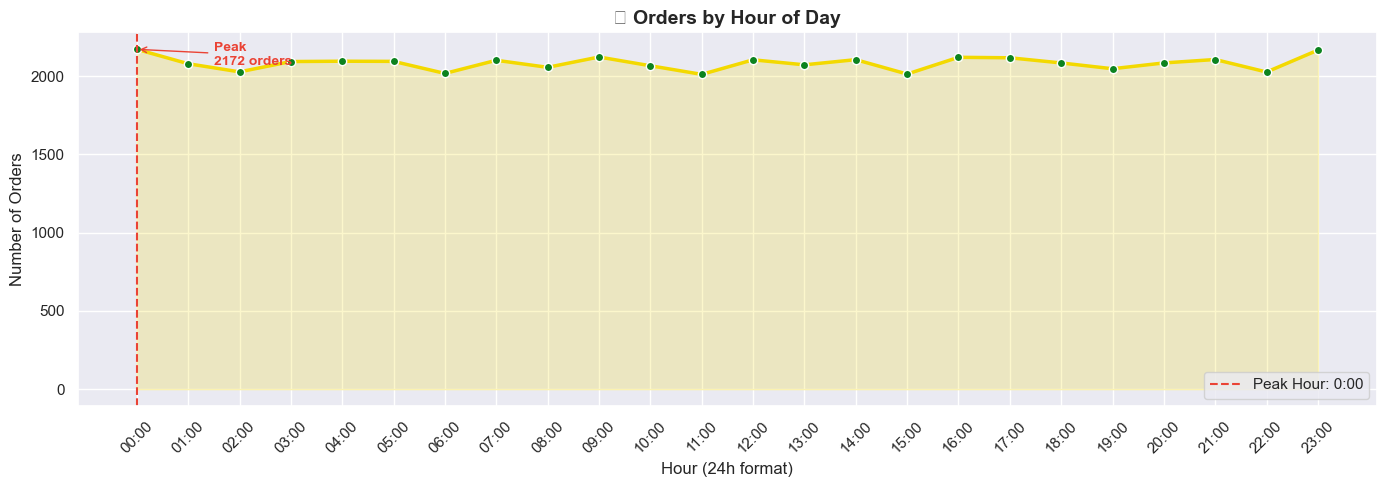

✅ Chart saved!


In [24]:
plt.figure(figsize=(14, 5))

plt.plot(hour_orders['hour'], hour_orders['total_orders'],
         color='#F3D900', linewidth=2.5,
         marker='o', markersize=6,
         markerfacecolor='#0C831F', markeredgecolor='white')

plt.fill_between(hour_orders['hour'], hour_orders['total_orders'],
                 alpha=0.2, color='#F3D900')

# Highlight the peak hour
peak_hour = hour_orders.loc[hour_orders['total_orders'].idxmax(), 'hour']
peak_val  = hour_orders['total_orders'].max()

plt.axvline(peak_hour, color='#ea4335', linewidth=1.5,
            linestyle='--', label=f'Peak Hour: {peak_hour}:00')

plt.annotate(f'Peak\n{peak_val} orders',
             xy=(peak_hour, peak_val),
             xytext=(peak_hour + 1.5, peak_val - 100),
             fontsize=10, color='#ea4335', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#ea4335'))

plt.title('⏰ Orders by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (24h format)')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24), [f'{h:02d}:00' for h in range(0, 24)], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/03_peak_hours.png', dpi=150)
plt.show()
print("✅ Chart saved!")

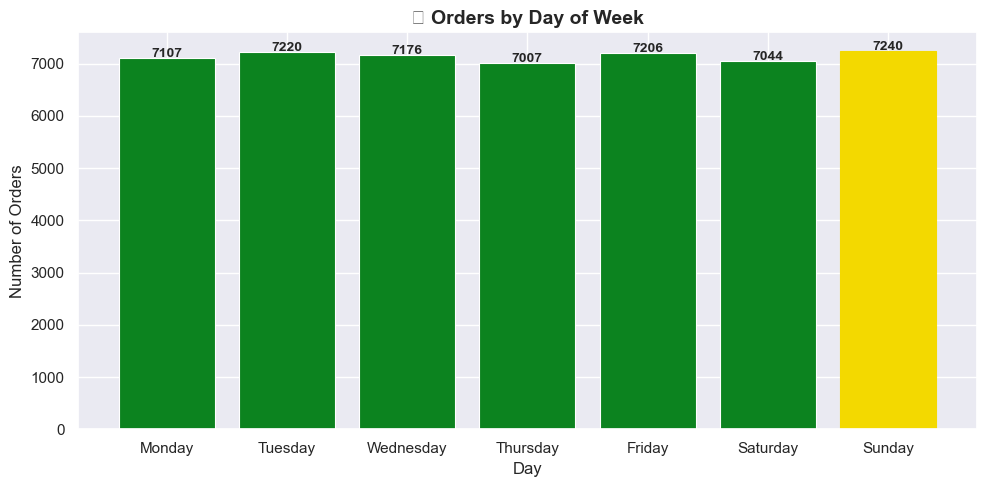

✅ Chart saved!


In [25]:
# Define correct day order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_orders = orders.groupby('day_name')['order_id'].count().reindex(day_order)

plt.figure(figsize=(10, 5))

bars = plt.bar(day_orders.index, day_orders.values,
               color='#0C831F', edgecolor='white', linewidth=0.8)

# Highlight highest day
max_day = day_orders.idxmax()
for bar, day in zip(bars, day_order):
    if day == max_day:
        bar.set_color('#F3D900')

# Add value labels
for bar, val in zip(bars, day_orders.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 20, str(val),
             ha='center', fontsize=10, fontweight='bold')

plt.title('📅 Orders by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/04_day_orders.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [26]:
# Total revenue by category
cat_sales = order_items.groupby('category')['total_price'].sum().sort_values(ascending=False)

# Total units sold by category
cat_qty = order_items.groupby('category')['quantity'].sum().sort_values(ascending=False)

# Average margin by category
cat_margin = order_items.groupby('category')['margin_percentage'].mean().sort_values(ascending=False)

print("Top categories by revenue:")
print(cat_sales)

Top categories by revenue:
category
Instant & Frozen Food    31401893.39
Baby Care                30243386.93
Cold Drinks & Juices     29820071.18
Pet Care                 25324425.52
Fruits & Vegetables      22439488.50
Snacks & Munchies        19791606.61
Household Care           18218937.51
Grocery & Staples        16349911.51
Personal Care            14138403.85
Dairy & Breakfast        13577476.16
Pharmacy                 11448606.83
Name: total_price, dtype: float64


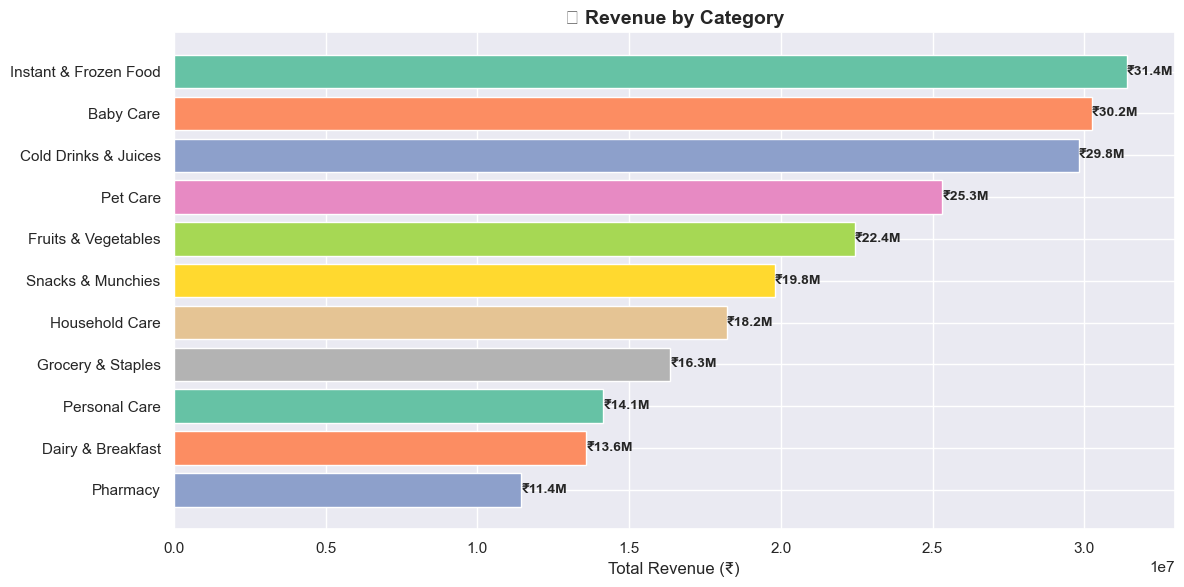

✅ Chart saved!


In [27]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette('Set2', len(cat_sales))
bars = plt.barh(cat_sales.index, cat_sales.values,
                color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, cat_sales.values):
    plt.text(val + 10000, bar.get_y() + bar.get_height()/2,
             f'₹{val/1e6:.1f}M',
             va='center', fontsize=10, fontweight='bold')

plt.title('💰 Revenue by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/05_category_revenue.png', dpi=150)
plt.show()
print("✅ Chart saved!")

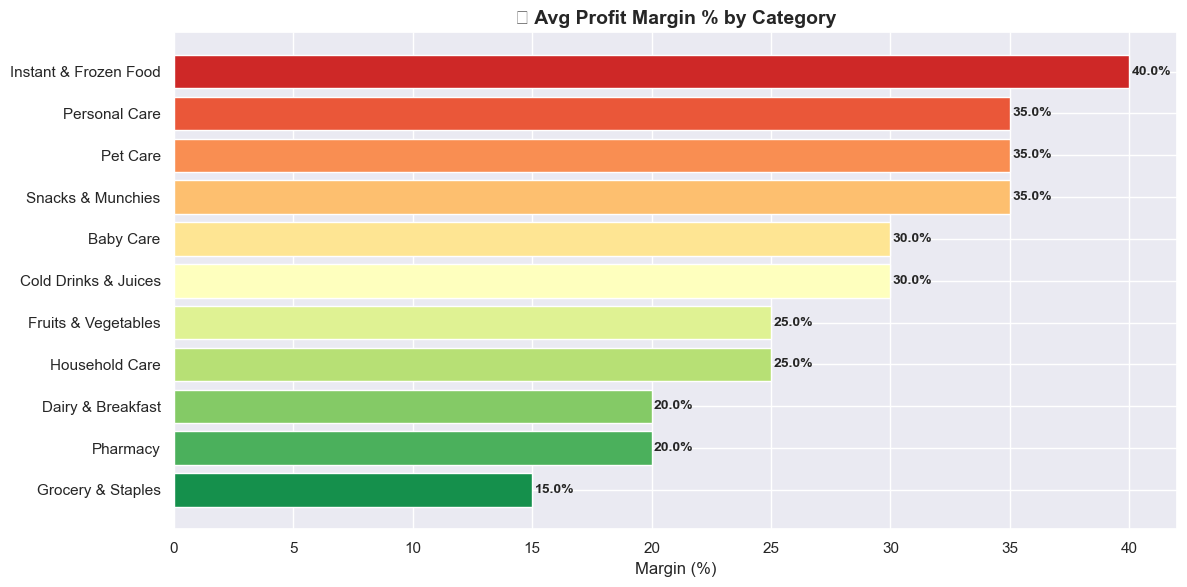

✅ Chart saved!


In [28]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette('RdYlGn', len(cat_margin))
bars = plt.barh(cat_margin.index, cat_margin.values,
                color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, cat_margin.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%',
             va='center', fontsize=10, fontweight='bold')

plt.title('📊 Avg Profit Margin % by Category', fontsize=14, fontweight='bold')
plt.xlabel('Margin (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/06_category_margin.png', dpi=150)
plt.show()
print("✅ Chart saved!")

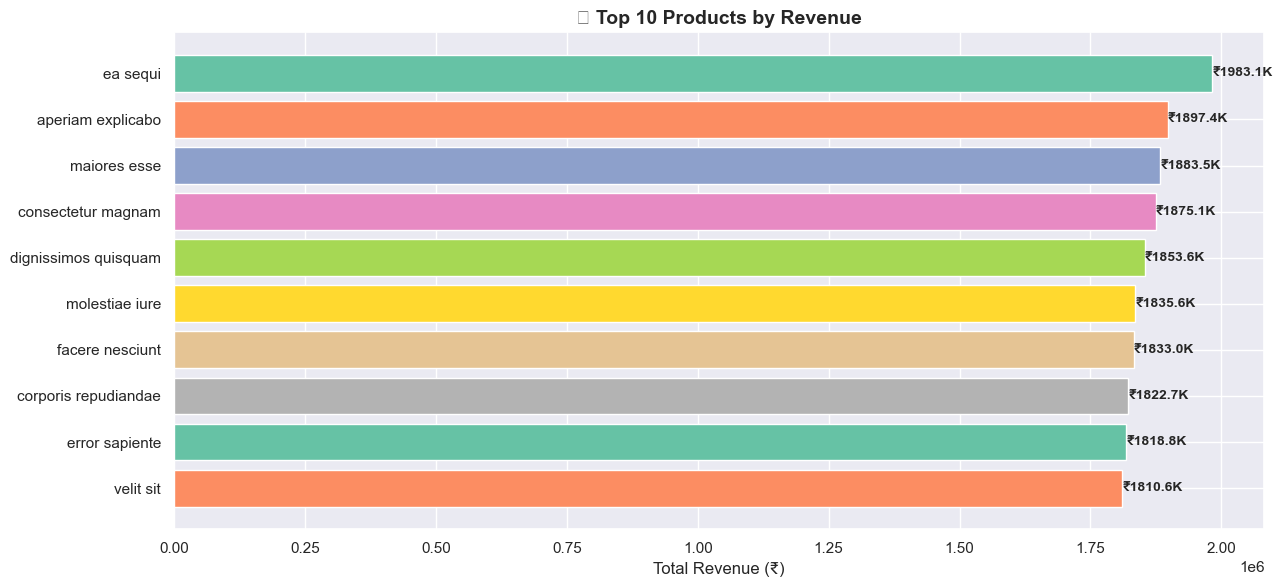

✅ Chart saved!


In [29]:
# Join product names into order_items
top_products = (
    order_items.groupby('product_id')['total_price'].sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .merge(products[['product_id','product_name','category']], on='product_id')
)

plt.figure(figsize=(13, 6))

colors = sns.color_palette('Set2', 10)
bars = plt.barh(top_products['product_name'], top_products['total_price'],
                color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, top_products['total_price']):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'₹{val/1e3:.1f}K',
             va='center', fontsize=10, fontweight='bold')

plt.title('🏆 Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/07_top_products.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [30]:
# Revenue by customer segment
seg_sales = master.groupby('customer_segment')['order_total'].sum().sort_values(ascending=False)

# Count of customers per segment
seg_count = customers['customer_segment'].value_counts()

# Top 10 areas by revenue
top_areas = master.groupby('area')['order_total'].sum().sort_values(ascending=False).head(10)

print("Revenue by Segment:")
print(seg_sales)
print("\nTop 5 Areas:")
print(top_areas.head())

Revenue by Segment:
customer_segment
Regular     29412100.64
Inactive    29311936.00
New         29123112.96
Premium     28388308.27
Name: order_total, dtype: float64

Top 5 Areas:
area
Ghaziabad     761534.99
Aurangabad    685725.22
Kharagpur     544954.42
Aizawl        498459.95
Bhopal        494898.22
Name: order_total, dtype: float64


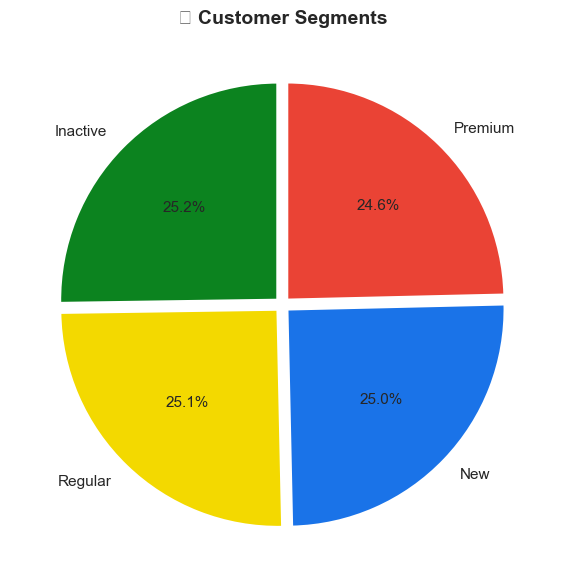

✅ Chart saved!


In [31]:
plt.figure(figsize=(8, 6))

colors = ['#0C831F', '#F3D900', '#1a73e8', '#ea4335']

plt.pie(seg_count.values,
        labels=seg_count.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        explode=[0.03, 0.03, 0.03, 0.03])

plt.title('👥 Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/08_customer_segments.png', dpi=150)
plt.show()
print("✅ Chart saved!")

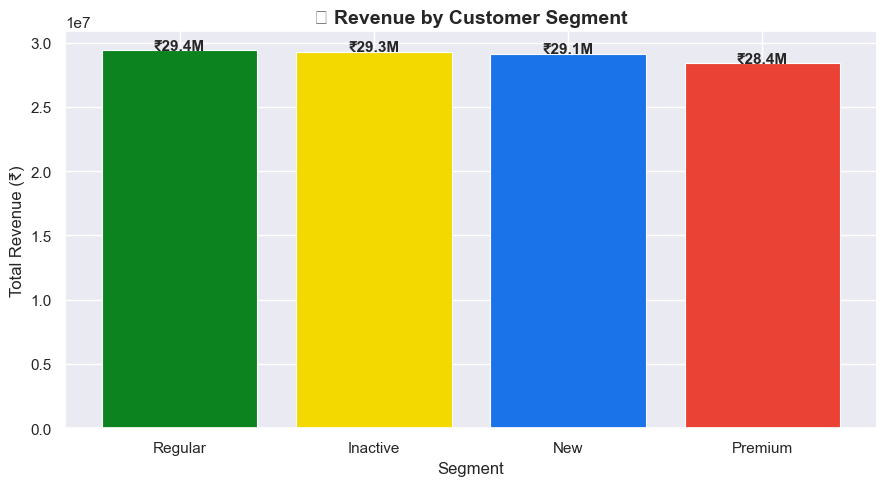

✅ Chart saved!


In [32]:
plt.figure(figsize=(9, 5))

colors = ['#0C831F', '#F3D900', '#1a73e8', '#ea4335']
bars = plt.bar(seg_sales.index, seg_sales.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on top
for bar, val in zip(bars, seg_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 50000,
             f'₹{val/1e6:.1f}M',
             ha='center', fontsize=11, fontweight='bold')

plt.title('💰 Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/09_segment_revenue.png', dpi=150)
plt.show()
print("✅ Chart saved!")

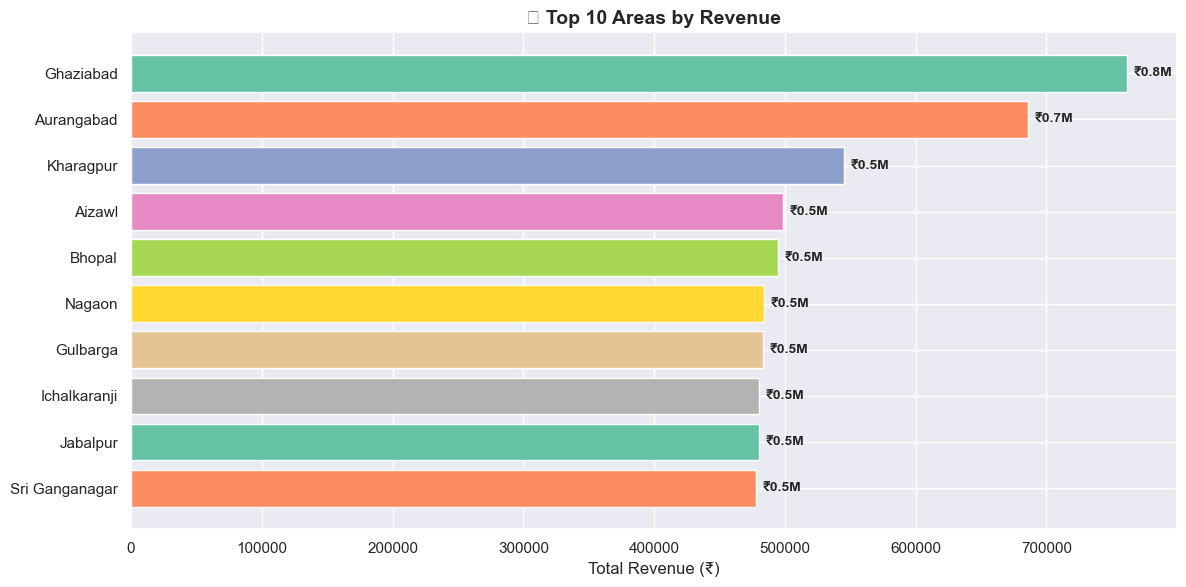

✅ Chart saved!


In [33]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette('Set2', 10)
bars = plt.barh(top_areas.index, top_areas.values,
                color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, top_areas.values):
    plt.text(val + 5000,
             bar.get_y() + bar.get_height()/2,
             f'₹{val/1e6:.1f}M',
             va='center', fontsize=10, fontweight='bold')

plt.title('📍 Top 10 Areas by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/10_top_areas.png', dpi=150)
plt.show()
print("✅ Chart saved!")

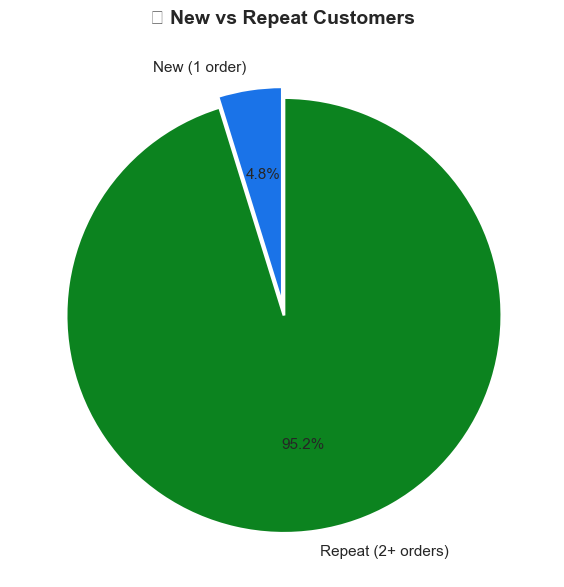

✅ Chart saved!


In [34]:
repeat_vals  = [
    (customers['total_orders'] == 1).sum(),
    (customers['total_orders'] > 1).sum()
]
repeat_labels = ['New (1 order)', 'Repeat (2+ orders)']

plt.figure(figsize=(7, 6))

plt.pie(repeat_vals,
        labels=repeat_labels,
        autopct='%1.1f%%',
        colors=['#1a73e8', '#0C831F'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        explode=[0, 0.05])

plt.title('🔄 New vs Repeat Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/11_repeat_customers.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [35]:
# Delivery status counts
status_counts = delivery['delivery_status'].value_counts()

# Delay reasons (only delayed orders)
delay_reasons = delivery[delivery['delivery_status'] != 'On Time']['reasons_if_delayed'].value_counts()

# Avg delivery time by status
avg_by_status = delivery.groupby('delivery_status')['delay_minutes'].mean()

print("Delivery Status:")
print(status_counts)
print("\nDelay Reasons:")
print(delay_reasons)

Delivery Status:
delivery_status
On Time                  35116
Slightly Delayed          9893
Significantly Delayed     4991
Name: count, dtype: int64

Delay Reasons:
reasons_if_delayed
Traffic    14884
Name: count, dtype: int64


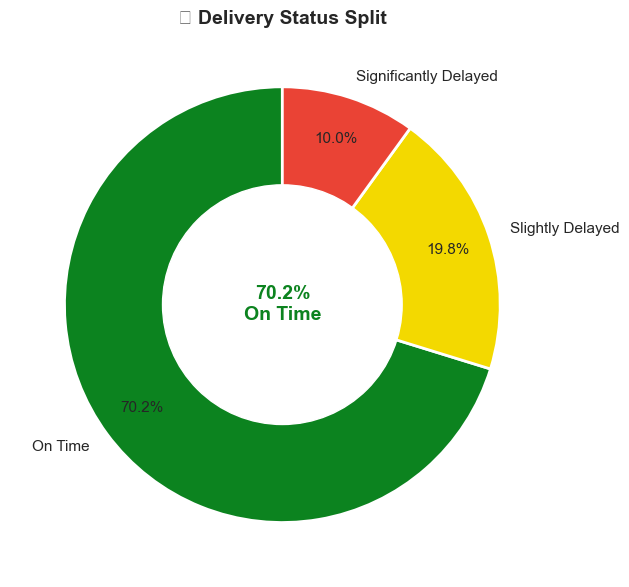

✅ Chart saved!


In [36]:
plt.figure(figsize=(8, 6))

colors = ['#0C831F', '#F3D900', '#ea4335']

wedges, texts, autotexts = plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.8)

# Make it a donut
centre = plt.Circle((0, 0), 0.55, color='white')
plt.gca().add_patch(centre)

# Add text in center
plt.text(0, 0, f'{status_counts["On Time"]/status_counts.sum()*100:.1f}%\nOn Time',
         ha='center', va='center', fontsize=14, fontweight='bold', color='#0C831F')

plt.title('✅ Delivery Status Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/12_delivery_status.png', dpi=150)
plt.show()
print("✅ Chart saved!")

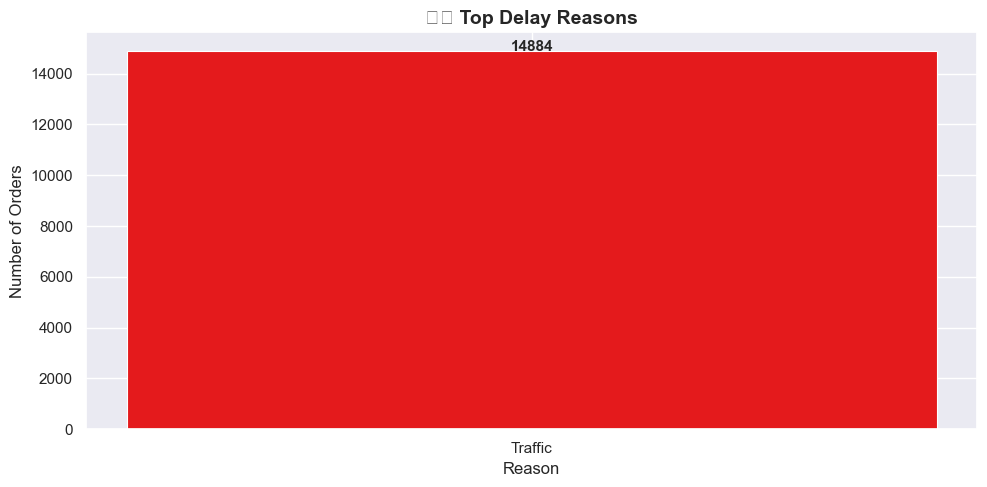

✅ Chart saved!


In [37]:
plt.figure(figsize=(10, 5))

colors = sns.color_palette('Set1', len(delay_reasons))
bars = plt.bar(delay_reasons.index, delay_reasons.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, delay_reasons.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 20,
             str(val),
             ha='center', fontsize=11, fontweight='bold')

plt.title('⚠️ Top Delay Reasons', fontsize=14, fontweight='bold')
plt.xlabel('Reason')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/13_delay_reasons.png', dpi=150)
plt.show()
print("✅ Chart saved!")

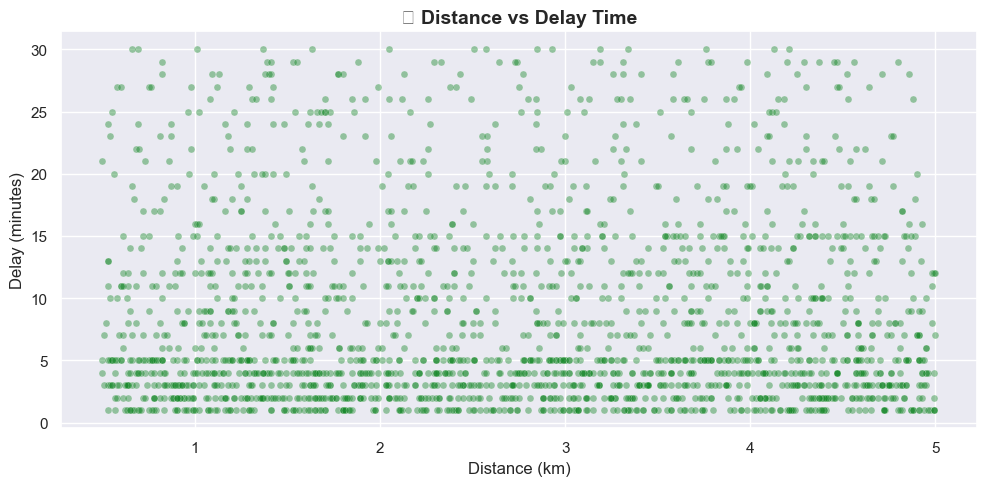

✅ Chart saved!


In [38]:
# Take sample of 2000 delayed orders only
sample = delivery[delivery['delay_minutes'] > 0].sample(n=2000, random_state=42)

plt.figure(figsize=(10, 5))

plt.scatter(sample['distance_km'], sample['delay_minutes'],
            alpha=0.4, color='#0C831F',
            edgecolors='white', linewidth=0.3, s=25)

plt.title('📏 Distance vs Delay Time', fontsize=14, fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Delay (minutes)')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/14_distance_delay.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [39]:
# Rating distribution
rating_dist = feedback['rating'].value_counts().sort_index()

# Sentiment counts
sentiment = feedback['sentiment'].value_counts()

# Avg rating by feedback category
fb_category = feedback.groupby('feedback_category')['rating'].mean().sort_values(ascending=False)

print("Rating Distribution:")
print(rating_dist)
print("\nSentiment:")
print(sentiment)
print("\nAvg Rating by Category:")
print(fb_category)

Rating Distribution:
rating
1     1702
2     1624
3     6576
4    22614
5    17484
Name: count, dtype: int64

Sentiment:
sentiment
Positive    35116
Neutral      9893
Negative     4991
Name: count, dtype: int64

Avg Rating by Category:
feedback_category
Customer Service    4.057100
App Experience      4.055564
Product Quality     4.051627
Delivery            4.039929
Name: rating, dtype: float64


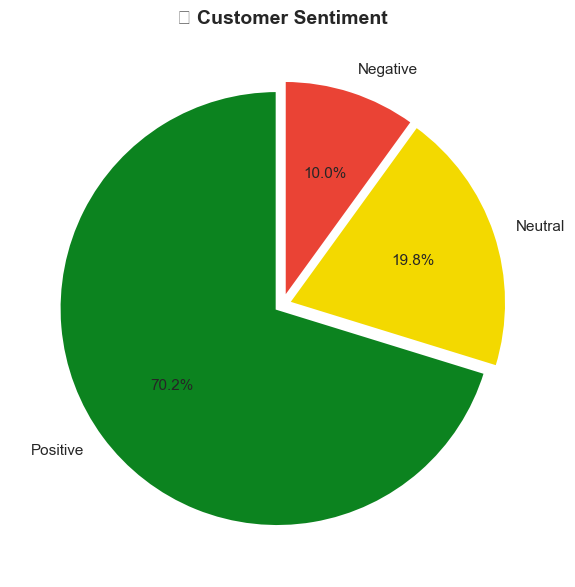

✅ Chart saved!


In [40]:
plt.figure(figsize=(8, 6))

colors = ['#0C831F', '#F3D900', '#ea4335']

plt.pie(sentiment.values,
        labels=sentiment.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        explode=[0.03, 0.03, 0.03])

plt.title('💬 Customer Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/16_sentiment.png', dpi=150)
plt.show()
print("✅ Chart saved!")

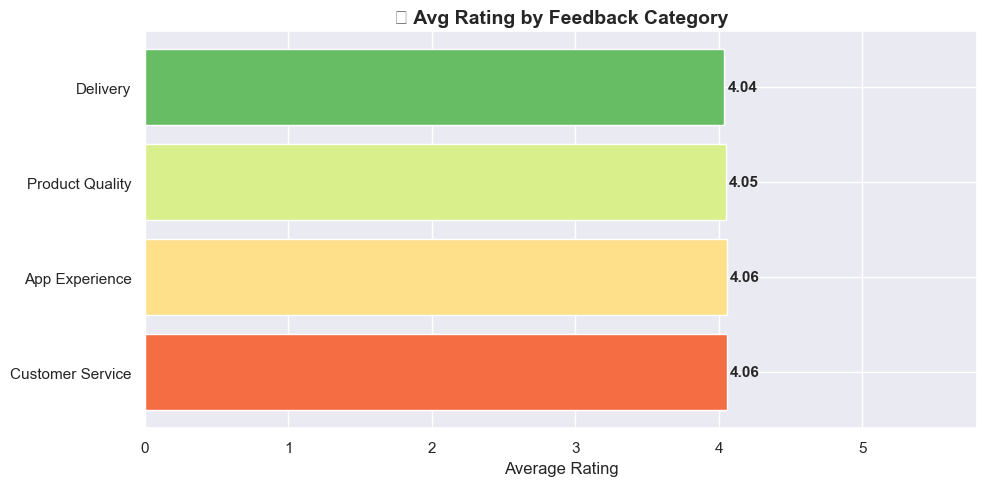

✅ Chart saved!


In [41]:
plt.figure(figsize=(10, 5))

colors = sns.color_palette('RdYlGn', len(fb_category))
bars = plt.barh(fb_category.index, fb_category.values,
                color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, fb_category.values):
    plt.text(val + 0.02,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}',
             va='center', fontsize=11, fontweight='bold')

plt.title('📝 Avg Rating by Feedback Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.xlim(0, 5.8)
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/17_rating_by_category.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [42]:
# Group by channel
channel_perf = marketing.groupby('channel').agg(
    total_spend       = ('spend', 'sum'),
    total_revenue     = ('revenue_generated', 'sum'),
    avg_roas          = ('roas', 'mean'),
    total_conversions = ('conversions', 'sum'),
    total_clicks      = ('clicks', 'sum'),
    total_impressions = ('impressions', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

# Click through rate
channel_perf['ctr'] = channel_perf['total_clicks'] / channel_perf['total_impressions'] * 100

print(channel_perf[['channel','total_spend','total_revenue','avg_roas','ctr']])

        channel  total_spend  total_revenue  avg_roas        ctr
0           App    192584.72      772373.01  2.725068  24.758634
2           SMS    183011.34      737871.04  2.758537  24.930033
1         Email    184336.91      735342.27  2.746481  25.133941
3  Social Media    181143.77      727951.70  2.723492  24.884112


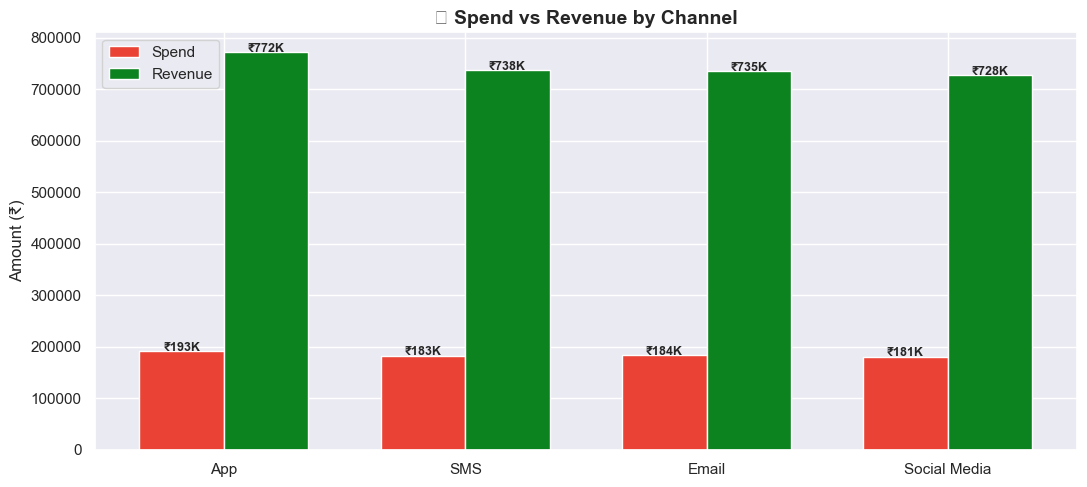

✅ Chart saved!


In [43]:
x = range(len(channel_perf))
w = 0.35

plt.figure(figsize=(11, 5))

bars1 = plt.bar([i - w/2 for i in x], channel_perf['total_spend'],
                width=w, label='Spend', color='#ea4335', edgecolor='white')

bars2 = plt.bar([i + w/2 for i in x], channel_perf['total_revenue'],
                width=w, label='Revenue', color='#0C831F', edgecolor='white')

# Add value labels
for bar, val in zip(bars1, channel_perf['total_spend']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 200,
             f'₹{val/1e3:.0f}K',
             ha='center', fontsize=9, fontweight='bold')

for bar, val in zip(bars2, channel_perf['total_revenue']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 200,
             f'₹{val/1e3:.0f}K',
             ha='center', fontsize=9, fontweight='bold')

plt.title('📣 Spend vs Revenue by Channel', fontsize=14, fontweight='bold')
plt.xticks(list(x), channel_perf['channel'])
plt.ylabel('Amount (₹)')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/18_spend_vs_revenue.png', dpi=150)
plt.show()
print("✅ Chart saved!")

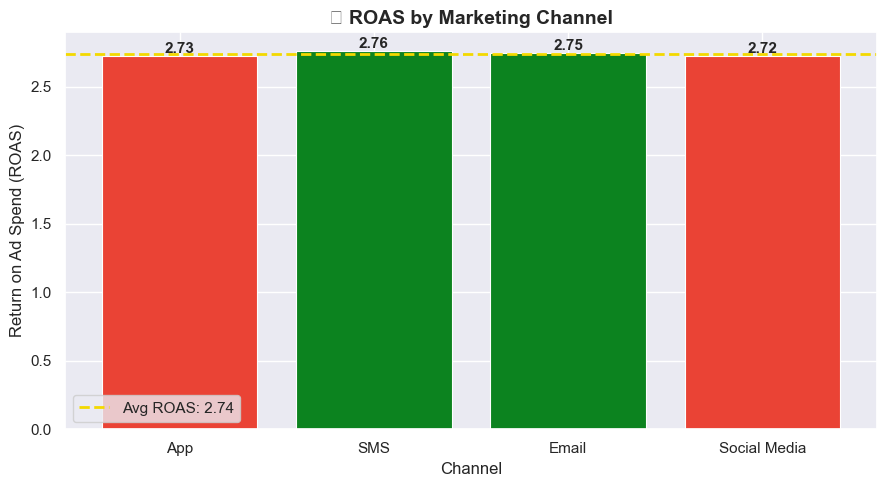

✅ Chart saved!


In [44]:
avg_roas_overall = channel_perf['avg_roas'].mean()

# Green if above average, red if below
colors = ['#0C831F' if v >= avg_roas_overall else '#ea4335'
          for v in channel_perf['avg_roas']]

plt.figure(figsize=(9, 5))

bars = plt.bar(channel_perf['channel'], channel_perf['avg_roas'],
               color=colors, edgecolor='white', linewidth=0.8)

# Average line
plt.axhline(avg_roas_overall, color='#F3D900', linewidth=2,
            linestyle='--', label=f'Avg ROAS: {avg_roas_overall:.2f}')

# Value labels
for bar, val in zip(bars, channel_perf['avg_roas']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.02,
             f'{val:.2f}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('📊 ROAS by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Return on Ad Spend (ROAS)')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/19_roas_by_channel.png', dpi=150)
plt.show()
print("✅ Chart saved!")

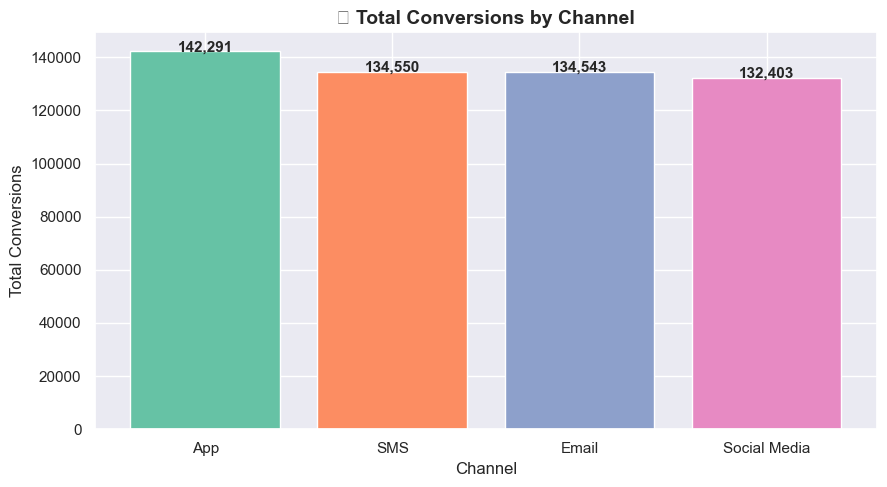

✅ Chart saved!


In [45]:
plt.figure(figsize=(9, 5))

colors = sns.color_palette('Set2', len(channel_perf))
bars = plt.bar(channel_perf['channel'], channel_perf['total_conversions'],
               color=colors, edgecolor='white')

# Value labels
for bar, val in zip(bars, channel_perf['total_conversions']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 50,
             f'{val:,}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('🎯 Total Conversions by Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Total Conversions')
plt.tight_layout()
plt.savefig(r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/20_conversions.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [46]:
import os

# Create a clean folder inside your dataset folder
output_path = r'C:/Users/KAUSHAL/Downloads/Blinkit dataset/clean_data/'
os.makedirs(output_path, exist_ok=True)

print(f"✅ Folder created: {output_path}")

✅ Folder created: C:/Users/KAUSHAL/Downloads/Blinkit dataset/clean_data/


In [47]:
# 1. Orders (with all time columns we added)
orders.to_csv(output_path + 'orders_clean.csv', index=False)
print("✅ orders_clean.csv exported")

# 2. Order Items (with category & margin joined)
order_items.to_csv(output_path + 'order_items_clean.csv', index=False)
print("✅ order_items_clean.csv exported")

# 3. Customers
customers.to_csv(output_path + 'customers_clean.csv', index=False)
print("✅ customers_clean.csv exported")

# 4. Products
products.to_csv(output_path + 'products_clean.csv', index=False)
print("✅ products_clean.csv exported")

# 5. Delivery (with delay_minutes fixed)
delivery.to_csv(output_path + 'delivery_clean.csv', index=False)
print("✅ delivery_clean.csv exported")

# 6. Feedback
feedback.to_csv(output_path + 'feedback_clean.csv', index=False)
print("✅ feedback_clean.csv exported")

# 7. Marketing
marketing.to_csv(output_path + 'marketing_clean.csv', index=False)
print("✅ marketing_clean.csv exported")

# 8. Inventory (with category joined)
inv_merged = inventory.merge(
    products[['product_id','category']], 
    on='product_id', how='left'
)
inv_merged.to_csv(output_path + 'inventory_clean.csv', index=False)
print("✅ inventory_clean.csv exported")

# 9. Master table (orders + customer area & segment)
master.to_csv(output_path + 'master_orders.csv', index=False)
print("✅ master_orders.csv exported")

✅ orders_clean.csv exported
✅ order_items_clean.csv exported
✅ customers_clean.csv exported
✅ products_clean.csv exported
✅ delivery_clean.csv exported
✅ feedback_clean.csv exported
✅ marketing_clean.csv exported
✅ inventory_clean.csv exported
✅ master_orders.csv exported


In [48]:
print("\n📁 Files in clean_data folder:")
print(f"{'File':<35} {'Size':>10}")
print("-" * 47)

for f in sorted(os.listdir(output_path)):
    size = os.path.getsize(output_path + f)
    print(f"{f:<35} {size/1024:>8.1f} KB")

print("\n🎉 Python EDA Complete!")
print("👉 Next Step: Open Power BI and import from clean_data folder")


📁 Files in clean_data folder:
File                                      Size
-----------------------------------------------
customers_clean.csv                   3428.5 KB
delivery_clean.csv                    4424.6 KB
feedback_clean.csv                    7224.4 KB
inventory_clean.csv                   9884.4 KB
marketing_clean.csv                    756.6 KB
master_orders.csv                     8301.0 KB
order_items_clean.csv                16174.5 KB
orders_clean.csv                      7502.4 KB
products_clean.csv                      19.7 KB

🎉 Python EDA Complete!
👉 Next Step: Open Power BI and import from clean_data folder


In [49]:
print("=" * 55)
print("        💡 BLINKIT — FINAL INSIGHTS SUMMARY")
print("=" * 55)
print(f"  💰 Total Revenue          : ₹{total_sales:,.0f}")
print(f"  🛒 Total Orders           : {total_orders:,}")
print(f"  👥 Unique Customers       : {total_customers:,}")
print(f"  🧾 Avg Order Value        : ₹{avg_order_value:,.2f}")
print(f"  ⏰ Peak Order Hour        : 12:00 AM")
print(f"  📦 Top Category           : Instant & Frozen Food")
print(f"  📍 Top Area               : Ghaziabad")
print(f"  💳 Top Payment Method     : Wallet")
print(f"  ✅ On-Time Delivery       : 70%")
print(f"  🚦 Top Delay Reason       : Traffic")
print(f"  ⭐ Avg Rating             : {avg_rating:.2f} / 5")
print(f"  💬 Positive Sentiment     : 70%")
print(f"  🔄 Repeat Customer Rate   : 95%")
print(f"  📣 Best ROAS Channel      : SMS")
print(f"  🎯 Most Conversions       : App")
print(f"  👑 Top Customer Segment   : Regular")
print("=" * 55)
print("\n✅ All charts saved in your Blinkit dataset folder")
print("✅ All clean CSVs ready in clean_data folder")
print("👉 Next: Power BI Dashboard!")

        💡 BLINKIT — FINAL INSIGHTS SUMMARY
  💰 Total Revenue          : ₹116,235,458
  🛒 Total Orders           : 50,000
  👥 Unique Customers       : 21,671
  🧾 Avg Order Value        : ₹2,324.71
  ⏰ Peak Order Hour        : 12:00 AM
  📦 Top Category           : Instant & Frozen Food
  📍 Top Area               : Ghaziabad
  💳 Top Payment Method     : Wallet
  ✅ On-Time Delivery       : 70%
  🚦 Top Delay Reason       : Traffic
  ⭐ Avg Rating             : 4.05 / 5
  💬 Positive Sentiment     : 70%
  🔄 Repeat Customer Rate   : 95%
  📣 Best ROAS Channel      : SMS
  🎯 Most Conversions       : App
  👑 Top Customer Segment   : Regular

✅ All charts saved in your Blinkit dataset folder
✅ All clean CSVs ready in clean_data folder
👉 Next: Power BI Dashboard!
